# Clean up FNO pipeline

This is for the 2D Darcy problem on [0, 1]^2, with input permeability field discrete in {0, 1}.

In [ ]:
# Imports
import numpy as np
import sys

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern

import torch
from torch.utils.data import DataLoader

import neuralop
from neuralop.models import FNO
from neuralop import Trainer, LpLoss, H1Loss
from neuralop.training import AdamW
from neuralop.data.datasets import load_darcy_flow_small, DarcyDataset
from neuralop.utils import count_model_params
from torch.nn import functional as F

import matplotlib.pyplot as plt


In [50]:
# ===== HYPERPARAMETERS =====

# === Data ===
data_n_train = 1_000
data_n_tests = [100, 50]
data_train_resolution = 64  # options: 16, 32, 64, 128, 421
data_test_resolutions = [64, 128]
data_batch_size = 32
data_test_batch_sizes = [32, 32]

# === Model ===
FNO_n_modes=(25, 25)  # these are the params which are saved. later change to (25,25). anyhow will have to vary for ablation study
FNO_in_channels=1
FNO_out_channels=1
FNO_hidden_channels=32  # Width of model. Documentation recommends 64, but 32 is sufficient for our purposes and much faster to train.
FNO_n_layers = 4  # Number of Fourier layers, the default
FNO_projection_channel_ratio=2
FNO_factorization="tucker"
FNO_rank=0.42
FNO_nonlinearity= F.gelu

# === Training ===
TRAIN_epochs = 150


In [51]:
def T_push(x, tau=-1, boundary=0):
    """A smooth approximation to the step function, which can be used to get a binary field from the GP sample while maintaining differentiability.
    See Akiyldiz for details.
    Combined with the option to get a hard threshold by setting tau=-1, based on the usual 3-12 normalisation.
    """
    if isinstance(x, np.ndarray):
        if tau == -1:
            return np.where(x < boundary, 3.0, 12.0)
        return 0.5 * np.tanh(tau * x) + 0.5
    else:  # torch tensor
        if tau == -1:
            return torch.where(x < boundary,
                               torch.tensor(3.0),
                               torch.tensor(12.0))
        return 0.5 * torch.tanh(tau * x) + 0.5

In [52]:
# Activate GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [53]:
# Import Data
# Loading the Darcy-Flow dataset

dataset = DarcyDataset(
    root_dir="./darcy_data",
    n_train=data_n_train,
    n_tests=data_n_tests,
    train_resolution=data_train_resolution,
    batch_size=data_batch_size,
    test_resolutions=data_test_resolutions,
    test_batch_sizes=data_test_batch_sizes,
)

# renormalise data to 3-12 range, as per convention. For some reason the default normalisation is 0-1 which is not the norm
# only run the code ONCE, otherwise it will normalise twice and all entries become 12.
for test_set in dataset.test_dbs.values():
    test_set.x = T_push(test_set.x, tau=-1, boundary=0.5)

dataset._train_db.x = T_push(dataset._train_db.x, tau=-1, boundary=0.5)


train_loader = DataLoader(
        dataset.train_db,
        batch_size=data_batch_size,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

test_loaders = {}
for res, test_bsize in zip(data_test_resolutions, data_test_batch_sizes):
    test_loaders[res] = DataLoader(
        dataset.test_dbs[res],
        batch_size=test_bsize,
        shuffle=False,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

data_processor = dataset.data_processor



Loading test db for resolution 64 with 100 samples 
Loading test db for resolution 128 with 50 samples 


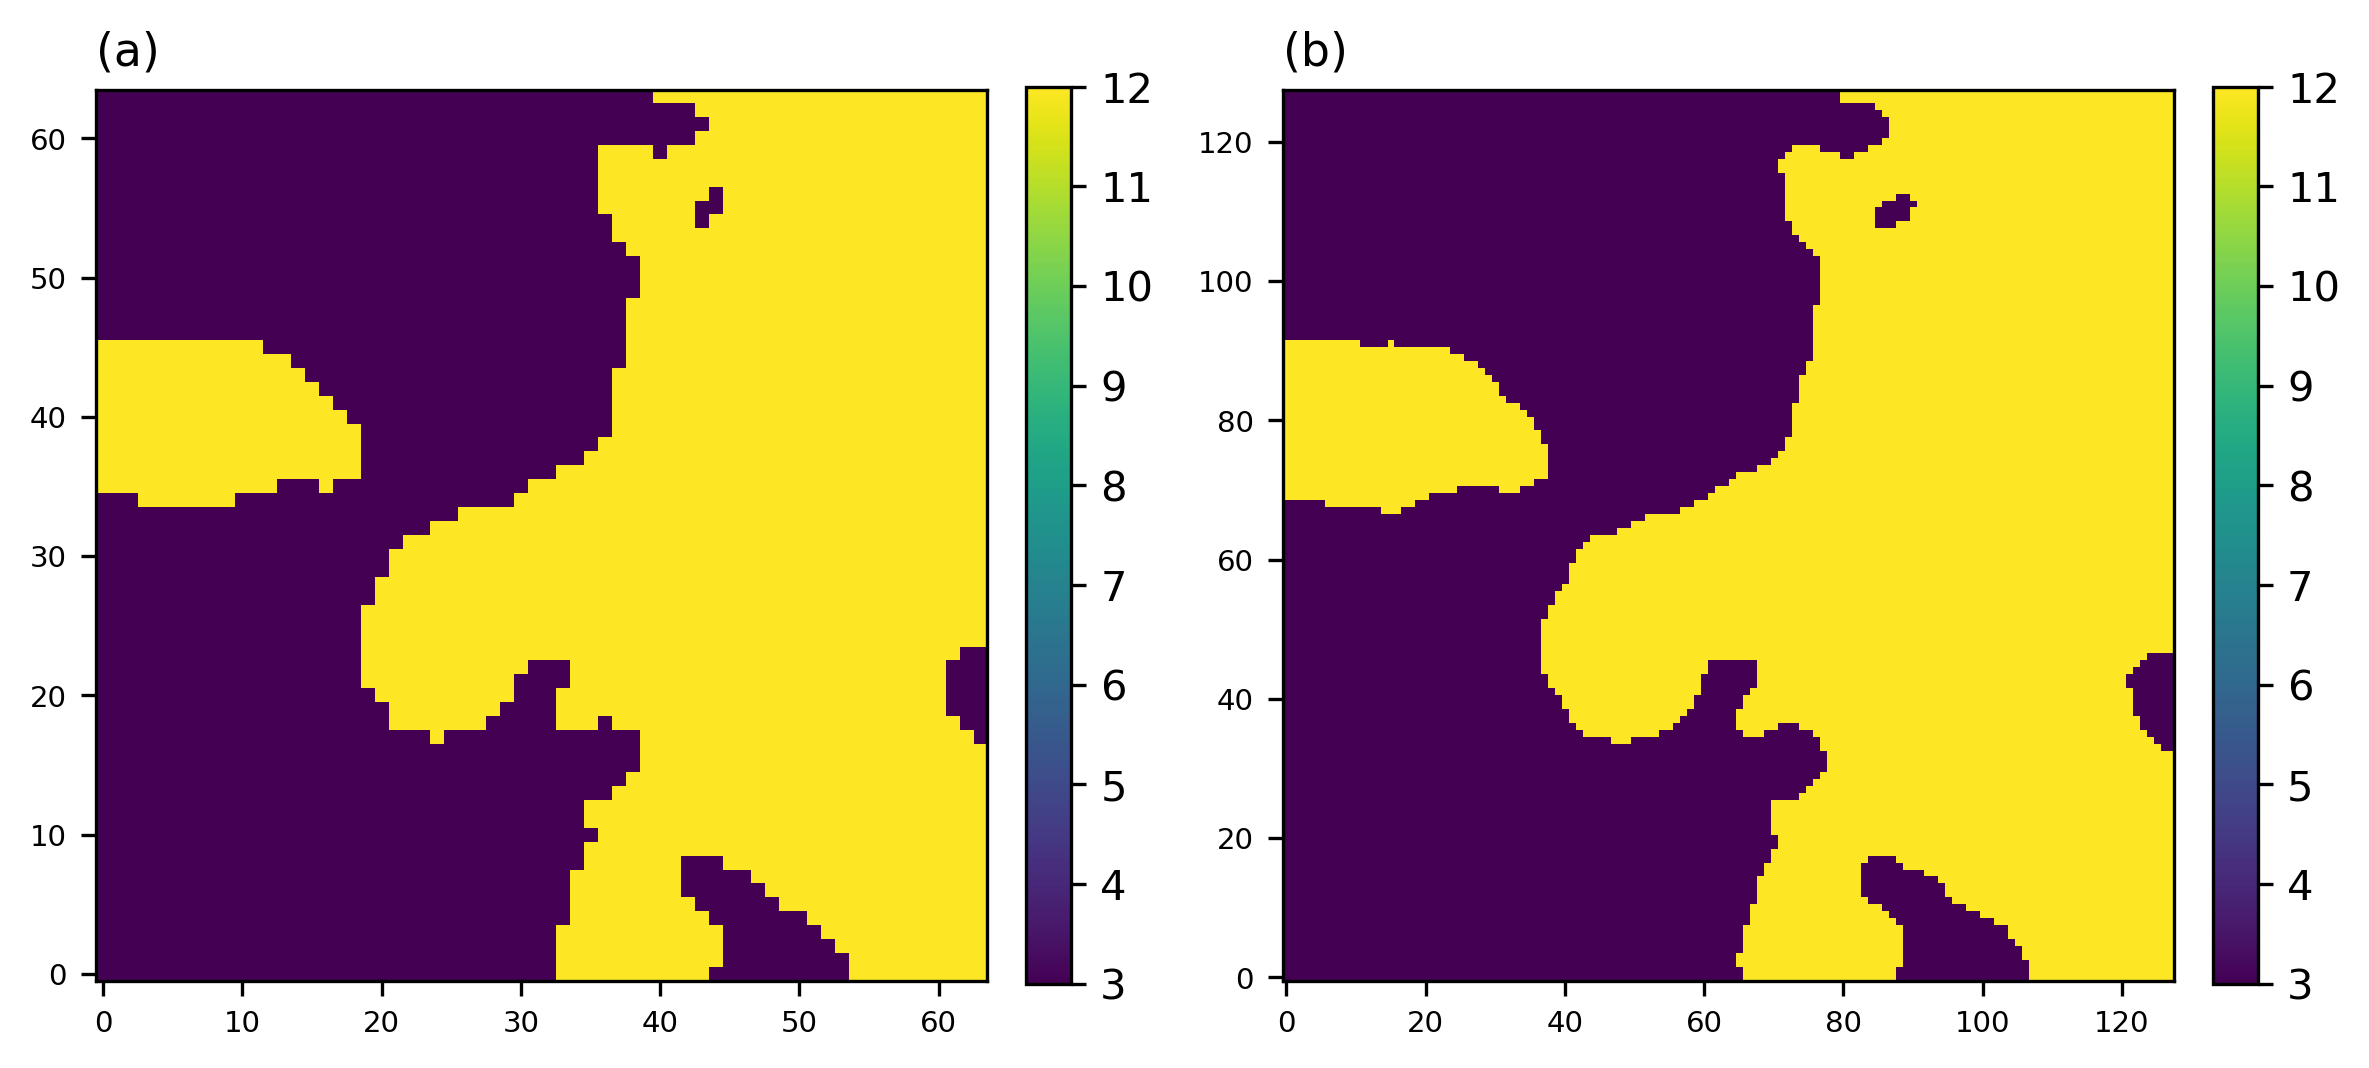

In [54]:
# visualise two examples of the field a(x)

tf1 = dataset.test_dbs[64][0]["x"]
tf2 = dataset.test_dbs[128][0]["x"]

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

for ax, tf, label in zip(axs, [tf1, tf2], ['(a)', '(b)']):
    im = ax.imshow(np.squeeze(tf), cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(label, fontsize=11, loc='left', pad=6)
    # ax.set_xticks(range(0,64, 2))
    # ax.set_yticks(range(0,64, 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# fig.suptitle('Coefficient field $a(x)$', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('coefficient_fields.png', bbox_inches='tight', dpi=300)
plt.show()

In [55]:
# Instantiate Model
model = FNO(
    n_modes=FNO_n_modes,
    in_channels=FNO_in_channels,
    out_channels=FNO_out_channels,
    hidden_channels=FNO_hidden_channels,
    n_layers=FNO_n_layers,
    # projection_channel_ratio=FNO_projection_channel_ratio,
    factorization=FNO_factorization,
    non_linearity=FNO_nonlinearity,
    # rank=FNO_rank,
)

# NOTE: FNO takes in inputs of shape (batch_size, in_channels, height, width) and outputs the same shape.
# If you want to pass a single observation, you need to add batch and channel dimensions, e.g., x[0, 0].unsqueeze(0).unsqueeze(0) to get shape (1, 1, 16, 16).

model = model.to(device)

n_params = count_model_params(model)
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush()


# Scheduler and Loss

optimizer = AdamW(model.parameters(), lr=8e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

train_loss = h1loss
eval_losses = {"h1": h1loss, "l2": l2loss}



Our model has 2698289 parameters.


In [56]:
# Train model
# Creating the trainer
trainer = Trainer(
    model=model,
    n_epochs=TRAIN_epochs,
    device=device,
    data_processor=data_processor,
    wandb_log=False,
    eval_interval=5,
    use_distributed=False,
    verbose=True,
)

# DELETE checkpoints FOLDER BEFORE TRAINING FROM SCRATCH
# We train and save checkpoints
# Train from scratch
trainer.train(
    train_loader=train_loader,
    test_loaders={},
    optimizer=optimizer,
    scheduler=scheduler,
    regularizer=False,
    training_loss=train_loss,
    save_every=5,
    save_dir="./checkpoints",
)

torch.serialization.add_safe_globals([torch._C._nn.gelu])
torch.serialization.add_safe_globals([neuralop.layers.spectral_convolution.SpectralConv])

# # Train from checkpoints
# trainer.train(
#     train_loader=train_loader,
#     test_loaders={},
#     optimizer=optimizer,
#     scheduler=scheduler,
#     regularizer=False,
#     training_loss=train_loss,
#     resume_from_dir="./checkpoints",
#     save_dir="./checkpoints",
# )

Training on 1000 samples
Testing on [] samples         on resolutions [].
Raw outputs of shape torch.Size([32, 1, 64, 64])


/home/ghazi/anaconda3/envs/darcy-env/lib/python3.11/site-packages/torch/nn/modules/module.py:1790: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)
/home/ghazi/anaconda3/envs/darcy-env/lib/python3.11/site-packages/neuralop/training/trainer.py:536: UserWarning: H1Loss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  loss += training_loss(out, **sample)


[0] time=1.29, avg_loss=0.8529, train_err=26.6543
Eval: 
[Rank 0]: saved training state to ./checkpoints
[5] time=1.21, avg_loss=0.2008, train_err=6.2755
Eval: 
[Rank 0]: saved training state to ./checkpoints
[10] time=1.12, avg_loss=0.1427, train_err=4.4582
Eval: 
[Rank 0]: saved training state to ./checkpoints
[15] time=1.11, avg_loss=0.1253, train_err=3.9152
Eval: 
[Rank 0]: saved training state to ./checkpoints
[20] time=1.16, avg_loss=0.0983, train_err=3.0714
Eval: 
[Rank 0]: saved training state to ./checkpoints
[25] time=1.18, avg_loss=0.0860, train_err=2.6864
Eval: 
[Rank 0]: saved training state to ./checkpoints
[30] time=1.12, avg_loss=0.0837, train_err=2.6142
Eval: 
[Rank 0]: saved training state to ./checkpoints
[35] time=1.12, avg_loss=0.0846, train_err=2.6424
Eval: 
[Rank 0]: saved training state to ./checkpoints
[40] time=1.12, avg_loss=0.0946, train_err=2.9550
Eval: 
[Rank 0]: saved training state to ./checkpoints
[45] time=1.15, avg_loss=0.1046, train_err=3.2689
Eval: 

In [ ]:
# === MCMC HYPERPARAMETERS ===
MCMC_delta = 0.0025  # can experiment later with adaptive delta, as in it gets smaller as the number of iterations increases.
MCMC_n_iterations = 20_000  # Most likely need it on the order of 100,000 to get good results, but we can test the code with fewer iterations first.
MCMC_tau = -1  # Smoothing parameter for the smooth threshold function. Higher values make it closer to a hard threshold, while lower values make it smoother. We can experiment with different values to see how it affects the results.


In [58]:
# MCMC helper functions

def log_likelihood(x: torch.Tensor, y: torch.Tensor, model, sigma=0.5275) -> torch.Tensor:
    """Inputs:
    - x: input tensor (location measurements of field θ)
    - y: observed output tensor (e.g., solution field u at locations x)
    - model: the trained FNO model that maps x to predicted y
    - sigma: standard deviation of the Gaussian likelihood
    Returns:
    - log-likelihood of observing y given x under the model's predictions"""
    # Ensure x and y are 4D tensors with shape (1, 1, height, width)
    # Ensure both x and y are on the same device as the model
    # x = x.to(device)
    # y = y.to(device)
    # Assuming Gaussian likelihood with fixed variance
    with torch.no_grad():
        forwards = model(x)
        mean = data_processor.out_normalizer.mean  # need to unnormalize the model outputs before comparing to y, since the model was trained on normalized data
        std = data_processor.out_normalizer.std
        forwards = forwards * std + mean
    forwards = forwards[0, 0]  # need .cpu() before .numpy()
    ll = -0.5 * torch.sum((y - forwards) ** 2).item() / sigma**2
    return ll


# Before the loop, build once:
_x_coords = np.linspace(0, 1, data_train_resolution)
_y_coords = np.linspace(0, 1, data_train_resolution)
_X, _Y = np.meshgrid(_x_coords, _y_coords)
_grid_points = np.column_stack([_X.ravel(), _Y.ravel()])
_gp = GaussianProcessRegressor(kernel=RBF(length_scale=0.3))

def sample_GP():
    sample = _gp.sample_y(_grid_points, n_samples=1, random_state=None)
    return sample.reshape(data_train_resolution, data_train_resolution)


# Before the loop
from sklearn.gaussian_process.kernels import Matern
# _kernel = RBF(length_scale=0.25)
_kernel = Matern(length_scale=0.3, nu=1) # nu=0.5 is even rougher
K_1d = _kernel(_x_coords.reshape(-1, 1))
K_1d += 1e-6 * np.eye(len(K_1d))
L_1d = np.linalg.cholesky(K_1d)


def sample_GP_kronecker():
    Z = np.random.randn(data_train_resolution, data_train_resolution)
    return L_1d @ Z @ L_1d.T


<class 'numpy.ndarray'>


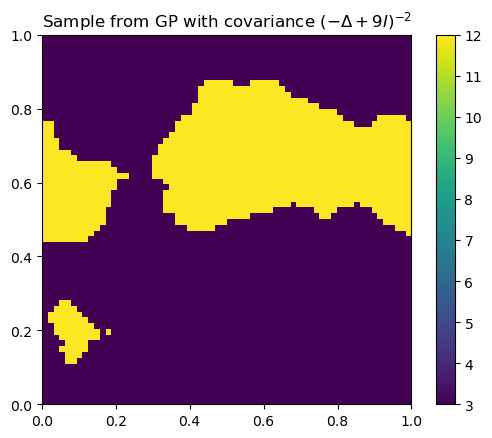

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# # grid size
# N = 64
# L = 1.0
# h = L / N

# def sample_GP_operator():
#     # Fourier frequencies
#     kx = 2 * np.pi * np.fft.fftfreq(N, d=h)
#     ky = 2 * np.pi * np.fft.fftfreq(N, d=h)

#     KX, KY = np.meshgrid(kx, ky, indexing='ij')

#     # eigenvalues of (-Δ + 9I)
#     A_eigs = KX**2 + KY**2 + 9.0

#     # covariance eigenvalues = A^{-2}
#     Cov_eigs = 1.0 / (A_eigs**2)

#     # white noise in Fourier space
#     z = np.random.randn(N, N) + 1j * np.random.randn(N, N)

#     # scale by sqrt(covariance eigenvalues)
#     u_hat = np.sqrt(Cov_eigs) * z

#     # transform back
#     u = np.fft.ifft2(u_hat).real
#     return u

N = 64    # physical grid resolution (unchanged)
M = 256   # oversampling factor — controls KL truncation level (M^2 terms)
L = 1.0


def sample_GP_operator(N=64, M=256):
    # Fine-grid wavenumbers — M^2 KL terms instead of N^2
    h_fine = 1 / M  # fine grid spacing for Fourier sampling
    kx = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)
    ky = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)

    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    # Eigenvalues on fine Fourier grid
    A_eigs = KX**2 + KY**2 + 9.0
    Cov_eigs = 1.0 / (A_eigs**2)

    # Sample M^2 independent KL coefficients
    z = np.random.randn(M, M) + 1j * np.random.randn(M, M)
    u_hat = np.sqrt(Cov_eigs) * z

    # IFFT on fine grid
    u_fine = np.fft.ifft2(u_hat).real * M**2  # shape (M, M)

    # Subsample back to coarse N x N grid
    step = M // N
    u_coarse = u_fine[::step, ::step]  # shape (N, N)
    
    return u_coarse

from scipy.ndimage import gaussian_filter

def sample_GP_operator_masked(u_current, bandwidth=0.1, smooth_sigma=2.0):
    """
    Sample a GP perturbation concentrated near the interface of u_current.
    
    bandwidth:    threshold on |u| to define the interface region.
                  In your domain u is real-valued after ifft2 — check
                  np.percentile(np.abs(u_current), 10) to calibrate this.
    smooth_sigma: Gaussian smoothing on the mask to avoid sharp cutoffs
                  creating spectral artifacts.
    """
    xi = sample_GP_operator()
    
    # Interface mask: near zero-crossings of u
    mask = (np.abs(u_current) < bandwidth).astype(float)
    mask = gaussian_filter(mask, sigma=smooth_sigma)
    
    # Renormalise so the masked sample has unit variance
    # (avoids the effective step size shrinking due to masking)
    if mask.max() > 1e-8:
        mask = mask / (mask.std() + 1e-8)
    
    return xi * mask


def sample_GP_operator_mixed(u_current, bandwidth=0.1, 
                               smooth_sigma=2.0, interface_weight=0.8):
    """
    Mixture proposal: interface-focused with probability interface_weight,
    global with probability (1 - interface_weight).
    
    The global component occasionally proposes large structural changes,
    preventing the chain from getting stuck in local topology.
    """
    if np.random.rand() < interface_weight:
        return sample_GP_operator_masked(u_current, bandwidth, smooth_sigma)
    else:
        return sample_GP_operator()


# visualize
sample = sample_GP_operator()
print(type(sample))
plt.imshow(T_push(sample_GP_operator(), tau=-1), extent=[0,1,0,1], origin='lower')
plt.colorbar()
plt.title(r'Sample from GP with covariance $(-\Delta + 9I)^{-2}$')
plt.show()

<class 'numpy.ndarray'>


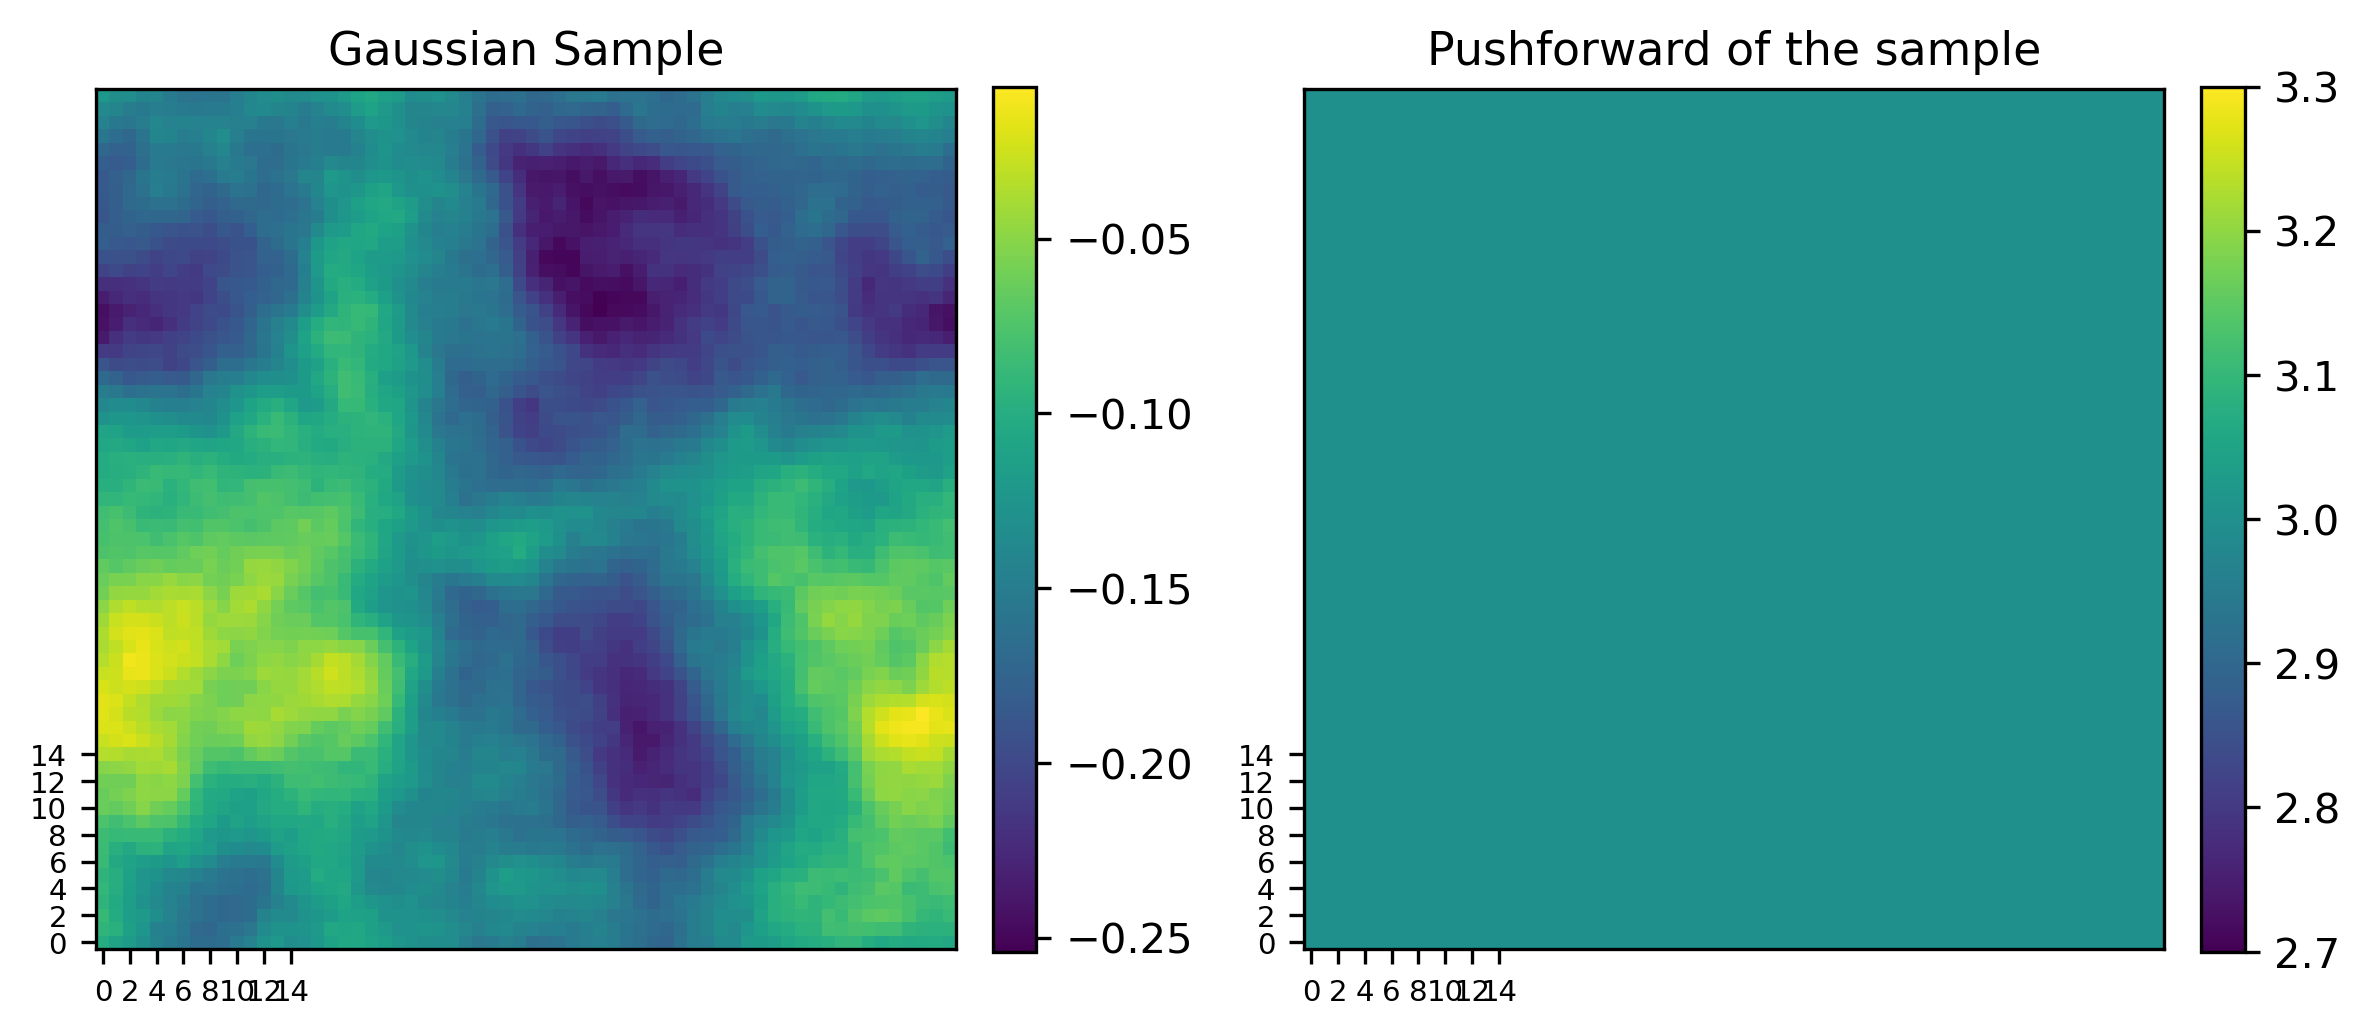

In [60]:
# visualise two examples of the field a(x)

tf1 = sample_GP_operator()
tf2 = T_push(tf1, tau=MCMC_tau)

print(type(tf1))
fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

for ax, tf, label in zip(axs, [tf1, tf2], ["Gaussian Sample", 'Pushforward of the sample']):
    im = ax.imshow(tf, cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(label, fontsize=11, loc='center', pad=6)
    ax.set_xticks(range(0,16, 2))
    ax.set_yticks(range(0,16, 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# fig.suptitle('Coefficient field $a(x)$', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('coefficient_fields.png', bbox_inches='tight', dpi=300)
plt.show()

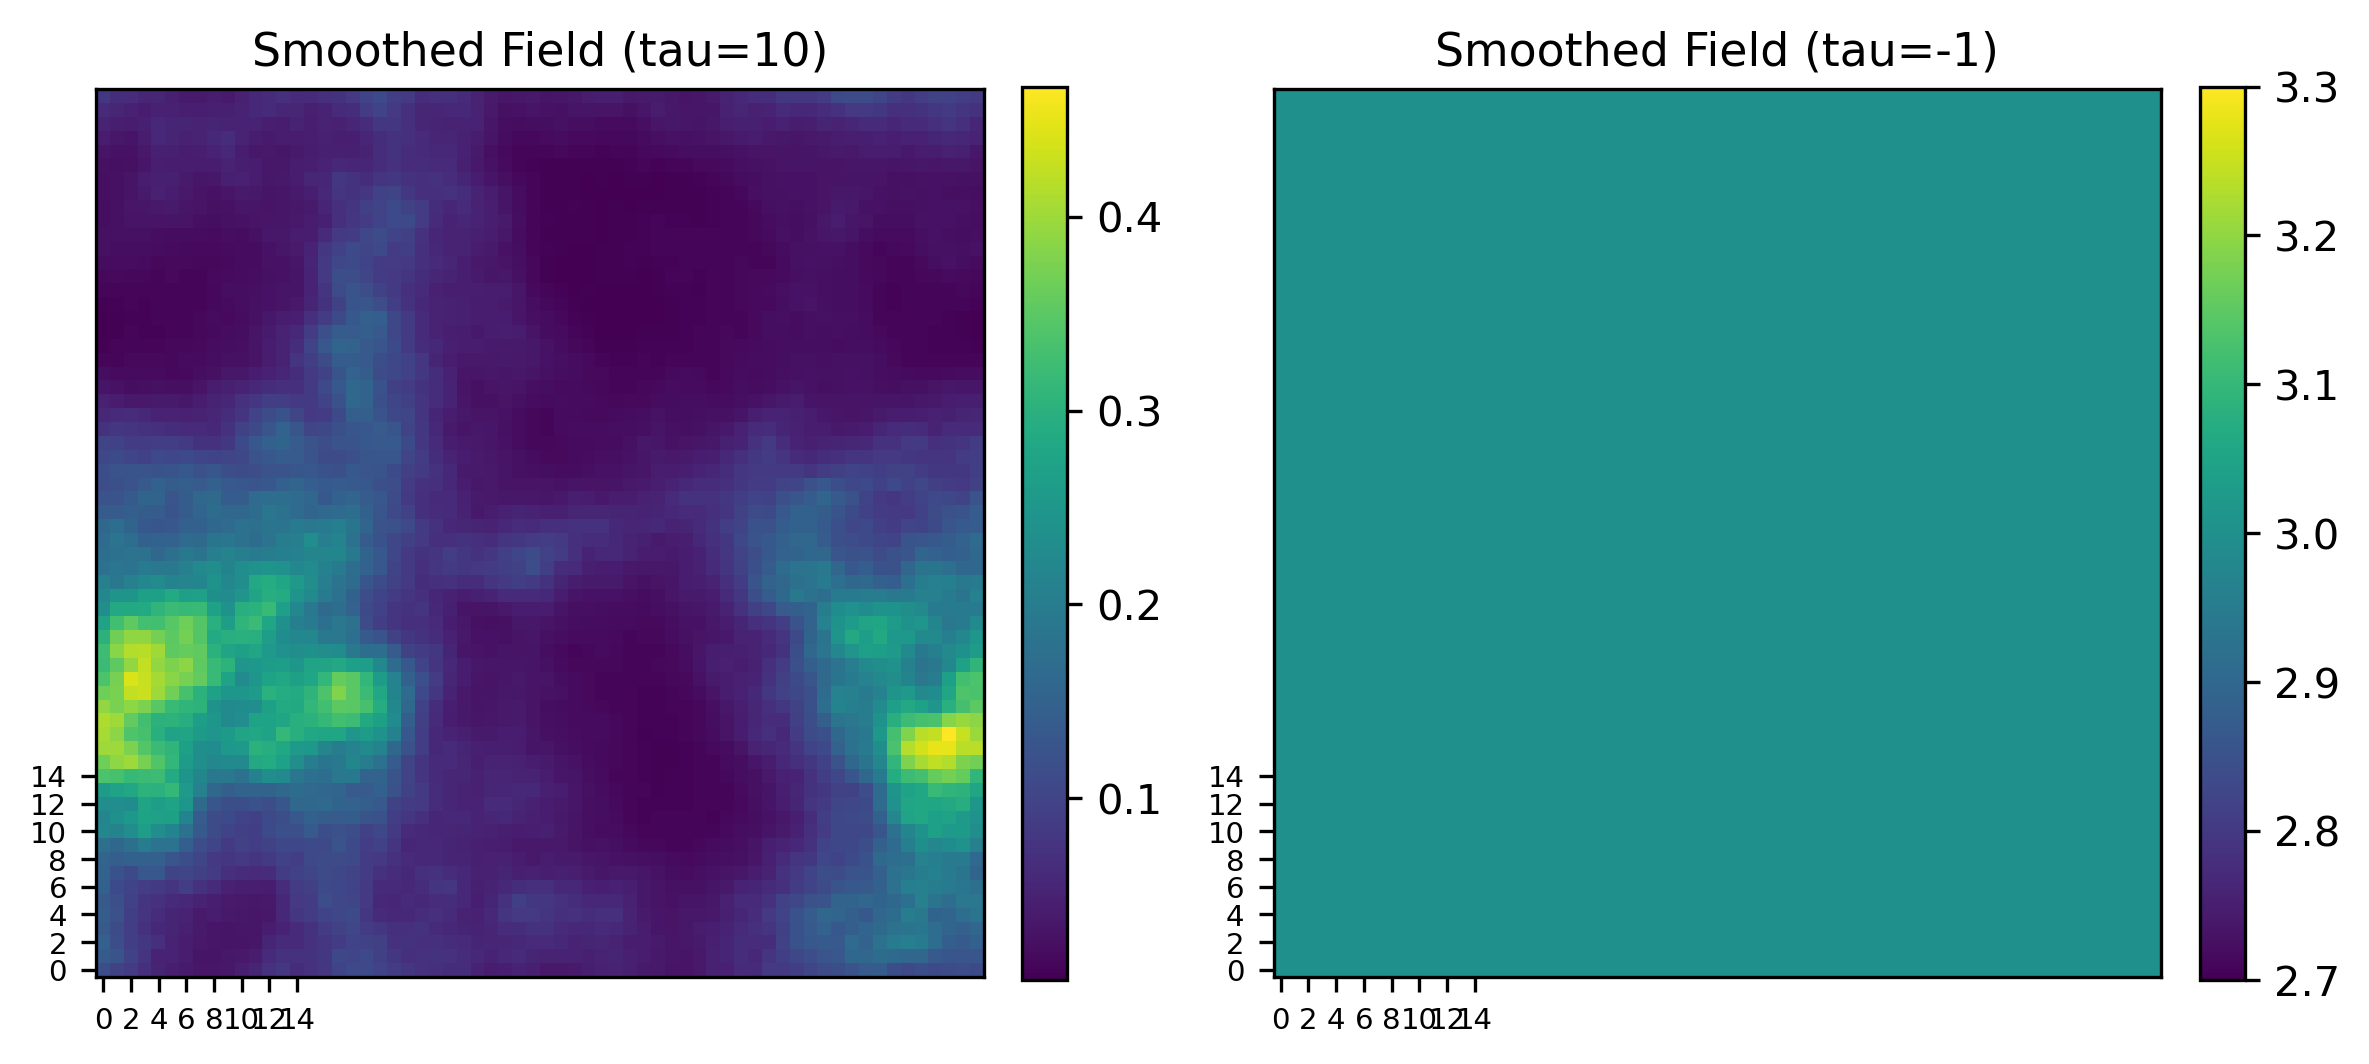

In [61]:
smooth1 = T_push(tf1, tau=10)
smooth2 = T_push(tf1, tau=-1)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

for ax, smooth, label in zip(axs, [smooth1, smooth2], ["Smoothed Field (tau=10)", "Smoothed Field (tau=-1)"]):
    im = ax.imshow(smooth, cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(label, fontsize=11, loc='center', pad=6)
    ax.set_xticks(range(0,16, 2))
    ax.set_yticks(range(0,16, 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# fig.suptitle('Coefficient field $a(x)$', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('tau_smooth_coefficient_fields.png', bbox_inches='tight', dpi=300)
plt.show()

In [62]:
# Get true field from test set
true_field = dataset.test_dbs[data_train_resolution].x[0, 0].unsqueeze(0).unsqueeze(0)  # shape (1, 1, train_resolution, train_resolution)
true_observations = dataset.test_dbs[data_train_resolution].y[0, 0].unsqueeze(0).unsqueeze(0)  # shape (1, 1, train_resolution, train_resolution)
sigma = true_observations.std().item()

# Instantiate MCMC
accepted = 0  # counter for accepted proposals
u_0 = sample_GP_operator()  # Initial proposal
theta_0 = T_push(u_0, tau=MCMC_tau)  # threshold to get binary field
theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
theta_evolution = [theta_0]  # to store the evolution of theta
loss_evolution = []
accepted = []

In [63]:
# Check these
print(true_observations.min(), true_observations.max(), true_observations.mean(), true_observations.std())

# And check what the model outputs raw
with torch.no_grad():
    raw_out = model(true_field.to(device))
print(raw_out.min(), raw_out.max(), raw_out.mean(), raw_out.std())

tensor(0.0002) tensor(0.9414) tensor(0.3594) tensor(0.2618)
tensor(-1.1828, device='cuda:0') tensor(1.6574, device='cuda:0') tensor(-0.0723, device='cuda:0') tensor(0.7958, device='cuda:0')


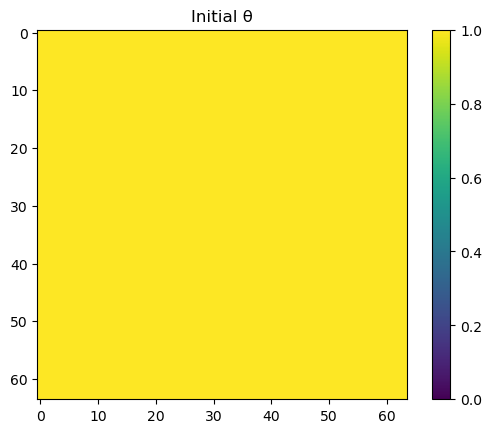

In [64]:
# Plot initial theta, to compare with how it evolves after MCMC loop
plt.imshow(theta_0, cmap='viridis', vmin=0, vmax=1)
plt.colorbar()
plt.title("Initial θ")
plt.show()

In [65]:
n_chains = 1
exploration_depth = 10
best_ll = -np.inf
best_theta = None
best_u = None  # track the latent GP variable
true_observations = true_observations.to(device)
for chain in range(n_chains):
    accepted = []
    u_0 = sample_GP_operator()
    theta_0 = T_push(u_0, tau=MCMC_tau)  # threshold to get binary field
    # Build tensor from the NEW theta_0, not the old one
    theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    ll_current = log_likelihood(theta_0_tensor, true_observations, model, sigma=sigma)
    for i in range(exploration_depth):
        # single MCMC step
        u_proposal = np.sqrt(1-2*MCMC_delta)*u_0 + np.sqrt(2*MCMC_delta)*sample_GP_operator()
        theta_proposal = T_push(u_proposal, tau=MCMC_tau)  # threshold to get binary field
        
        # Make proposals pytorch tensors, and add batch and channel dimensions to match FNO input shape (1, 1, n_sample, n_sample)
        theta_proposal_tensor = torch.tensor(theta_proposal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        # theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)


        # Inside the loop:
        ll_proposal = log_likelihood(theta_proposal_tensor, true_observations, model, sigma=sigma)
        acceptance_prob = min(1, np.exp(ll_proposal - ll_current))

        if np.random.rand() < acceptance_prob:
            theta_0 = theta_proposal
            u_0 = u_proposal
            theta_0_tensor = theta_proposal_tensor
            ll_current = ll_proposal  # reuse, don't recompute
            accepted += [1]
            theta_evolution.append(theta_0)
        else:
            accepted += [0]
        if (i+1) % 500 == 0:
            print(f"Iteration {i+1}/{exploration_depth}, Acceptance Rate: {sum(accepted[-1000:])/1000:.3f}")
    if ll_current > best_ll:
        best_ll = ll_current
        best_theta = theta_0
        best_u = u_0  # save the latent, not just the threshold

# Then run long chain from best starting point
print(best_theta)

[[3. 3. 3. ... 3. 3. 3.]
 [3. 3. 3. ... 3. 3. 3.]
 [3. 3. 3. ... 3. 3. 3.]
 ...
 [3. 3. 3. ... 3. 3. 3.]
 [3. 3. 3. ... 3. 3. 3.]
 [3. 3. 3. ... 3. 3. 3.]]


/tmp/ipykernel_119086/2388590234.py:26: RuntimeWarning: overflow encountered in exp
  acceptance_prob = min(1, np.exp(ll_proposal - ll_current))


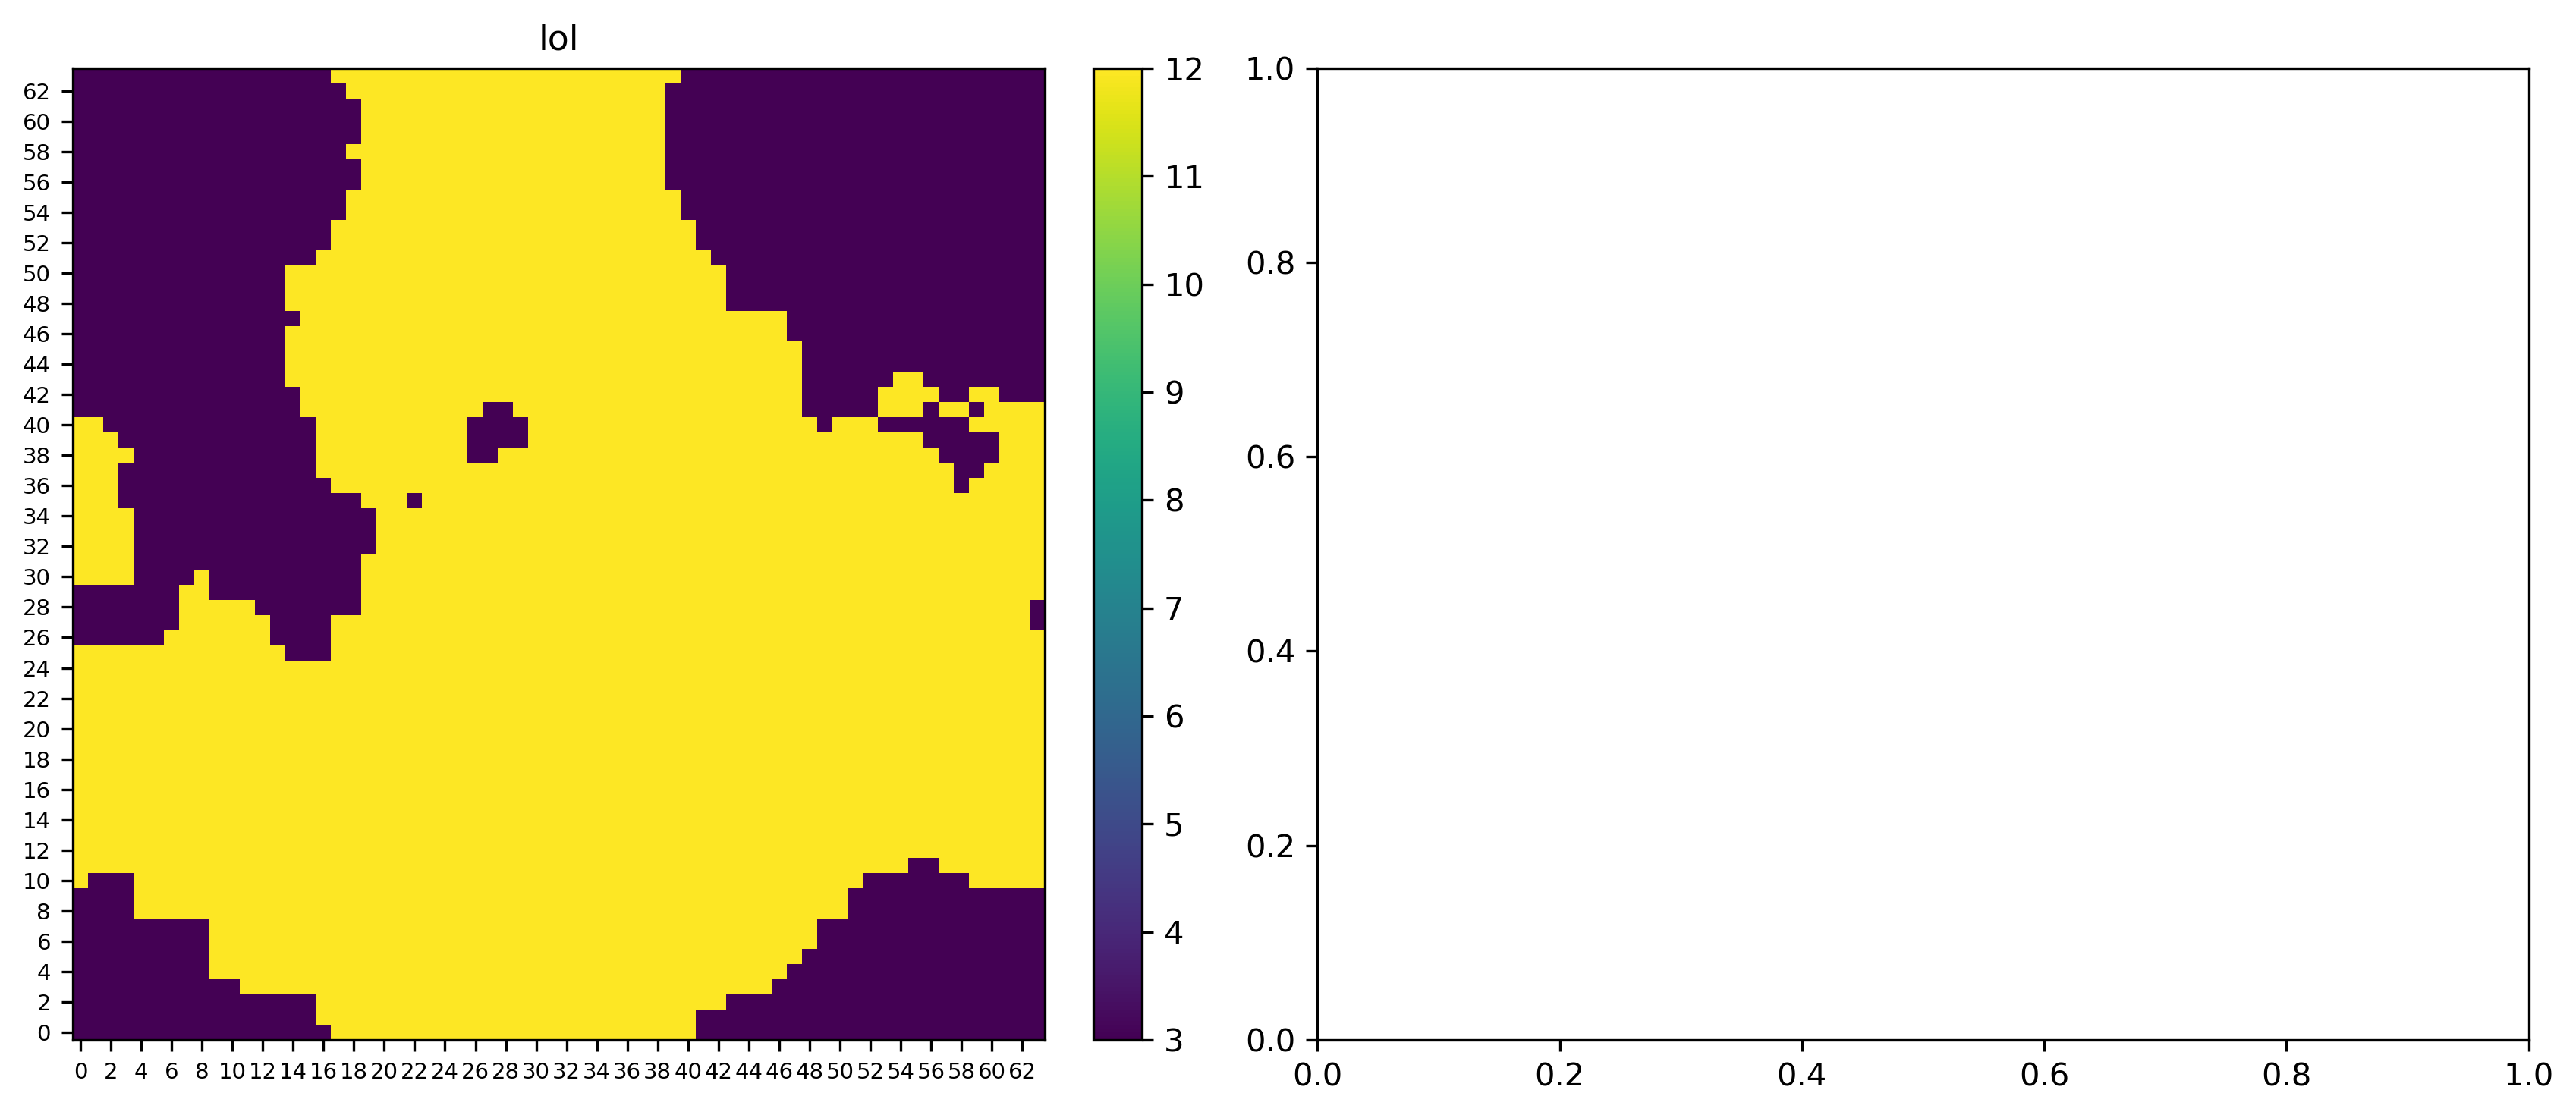

In [66]:
fig1, axs1 = plt.subplots(1, 2, figsize=(12, 5), dpi=300)
im = axs1[0].imshow(best_theta, cmap='viridis', interpolation='nearest', origin='lower')
axs1[0].set_title("lol", fontsize=11, loc='center', pad=6)
axs1[0].set_xticks(range(0, best_theta.shape[0], 2))
axs1[0].set_yticks(range(0, best_theta.shape[1], 2))
axs1[0].tick_params(labelsize=7)
plt.colorbar(im, ax=axs1[0], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [68]:
u_sample = sample_GP_operator()
print(np.percentile(np.abs(u_sample), [10, 25, 50]))
# Set bandwidth to roughly the 10th-25th percentile value

[0.00976937 0.02513678 0.05230619]


In [100]:
from collections import deque
import numpy as np
import torch

# === MCMC HYPERPARAMETERS ===
MCMC_delta = 0.00025  # can experiment later with adaptive delta, as in it gets smaller as the number of iterations increases.
MCMC_n_iterations = 40_000  # Most likely need it on the order of 100,000 to get good results, but we can test the code with fewer iterations first.
MCMC_tau = -1  # Smoothing parameter for the smooth threshold function. Higher values make it closer to a hard threshold, while lower values make it smoother. We can experiment with different values to see how it affects the results.

# --- Hyperparameters ---
target_acceptance = 0.234
adapt_interval    = 1_000        # match your existing print interval
delta_min, delta_max = 1e-6, 0.49   # keep sqrt(1-2δ) real, so δ < 0.5

nll_window = deque(maxlen=200)
n_accepted_window = 0           # resets every adapt_interval
theta_evolution = []
loss_evolution = []


true_observations = true_observations.to(device)
u_0 = best_u  # latent GP variable — correct starting point for pCN
theta_0 = best_theta
theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
ll_current = log_likelihood(theta_0_tensor, true_observations, model, sigma=sigma)
for i in range(MCMC_n_iterations):

    # --- Proposal (your original formula, unchanged) ---
    u_proposal     = np.sqrt(1 - 2 * MCMC_delta) * u_0 + np.sqrt(2 * MCMC_delta) * sample_GP_operator()
    theta_proposal = T_push(u_proposal, tau=MCMC_tau)
    theta_proposal_tensor = torch.tensor(theta_proposal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    # --- Accept / reject ---
    ll_proposal      = log_likelihood(theta_proposal_tensor, true_observations, model, sigma=sigma)
    acceptance_prob  = min(1, np.exp(ll_proposal - ll_current))

    if np.random.rand() < acceptance_prob:
        theta_0        = theta_proposal
        u_0            = u_proposal
        theta_0_tensor = theta_proposal_tensor
        ll_current     = ll_proposal
        accepted          += [1]
        n_accepted_window += 1
    else:
        accepted += [0]

    theta_evolution.append(theta_0)
    loss_evolution.append(ll_current)
    nll_window.append(-ll_current)      # store NLL (positive)

    # --- Adapt delta every adapt_interval steps ---
    if (i + 1) % adapt_interval == 0:
        acceptance_rate   = n_accepted_window / adapt_interval
        n_accepted_window = 0            # reset for next window

        # # Exponential scaling: nudge delta toward target acceptance
        # factor     = np.exp(acceptance_rate - target_acceptance)
        # MCMC_delta = float(np.clip(MCMC_delta * factor, delta_min, delta_max))

        avg_nll = np.mean(nll_window)
        # if acceptance_rate < target_acceptance:
        #     MCMC_delta /= 2  # divide by two if we're below target acceptance
        # elif acceptance_rate > 0.5:
        #     MCMC_delta *= 2  # multiply by two if we're above 0.5
        print(f"Iteration {i+1}/{MCMC_n_iterations} | "
              f"accept={acceptance_rate:.3f} | "
              f"delta={MCMC_delta:.5f} | "
              f"avg NLL (last 200)={avg_nll:.3f}")
        

Iteration 1000/40000 | accept=0.193 | delta=0.00025 | avg NLL (last 200)=554.097
Iteration 2000/40000 | accept=0.060 | delta=0.00025 | avg NLL (last 200)=245.430
Iteration 3000/40000 | accept=0.008 | delta=0.00025 | avg NLL (last 200)=243.003
Iteration 4000/40000 | accept=0.076 | delta=0.00025 | avg NLL (last 200)=144.644
Iteration 5000/40000 | accept=0.081 | delta=0.00025 | avg NLL (last 200)=67.546
Iteration 6000/40000 | accept=0.115 | delta=0.00025 | avg NLL (last 200)=45.888
Iteration 7000/40000 | accept=0.097 | delta=0.00025 | avg NLL (last 200)=39.446
Iteration 8000/40000 | accept=0.061 | delta=0.00025 | avg NLL (last 200)=38.779
Iteration 9000/40000 | accept=0.100 | delta=0.00025 | avg NLL (last 200)=30.864
Iteration 10000/40000 | accept=0.136 | delta=0.00025 | avg NLL (last 200)=28.132
Iteration 11000/40000 | accept=0.145 | delta=0.00025 | avg NLL (last 200)=25.156
Iteration 12000/40000 | accept=0.136 | delta=0.00025 | avg NLL (last 200)=24.440
Iteration 13000/40000 | accept=0.

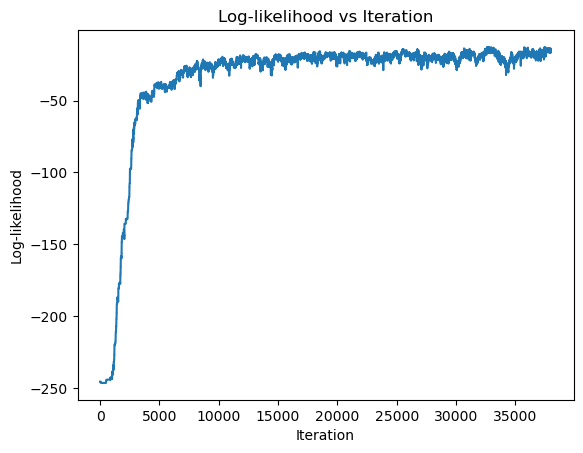

In [101]:
# Plot loss, compare predicted vs true_FNO vs absolute true
plt.plot(loss_evolution[2000:])
plt.title("Log-likelihood vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.show()

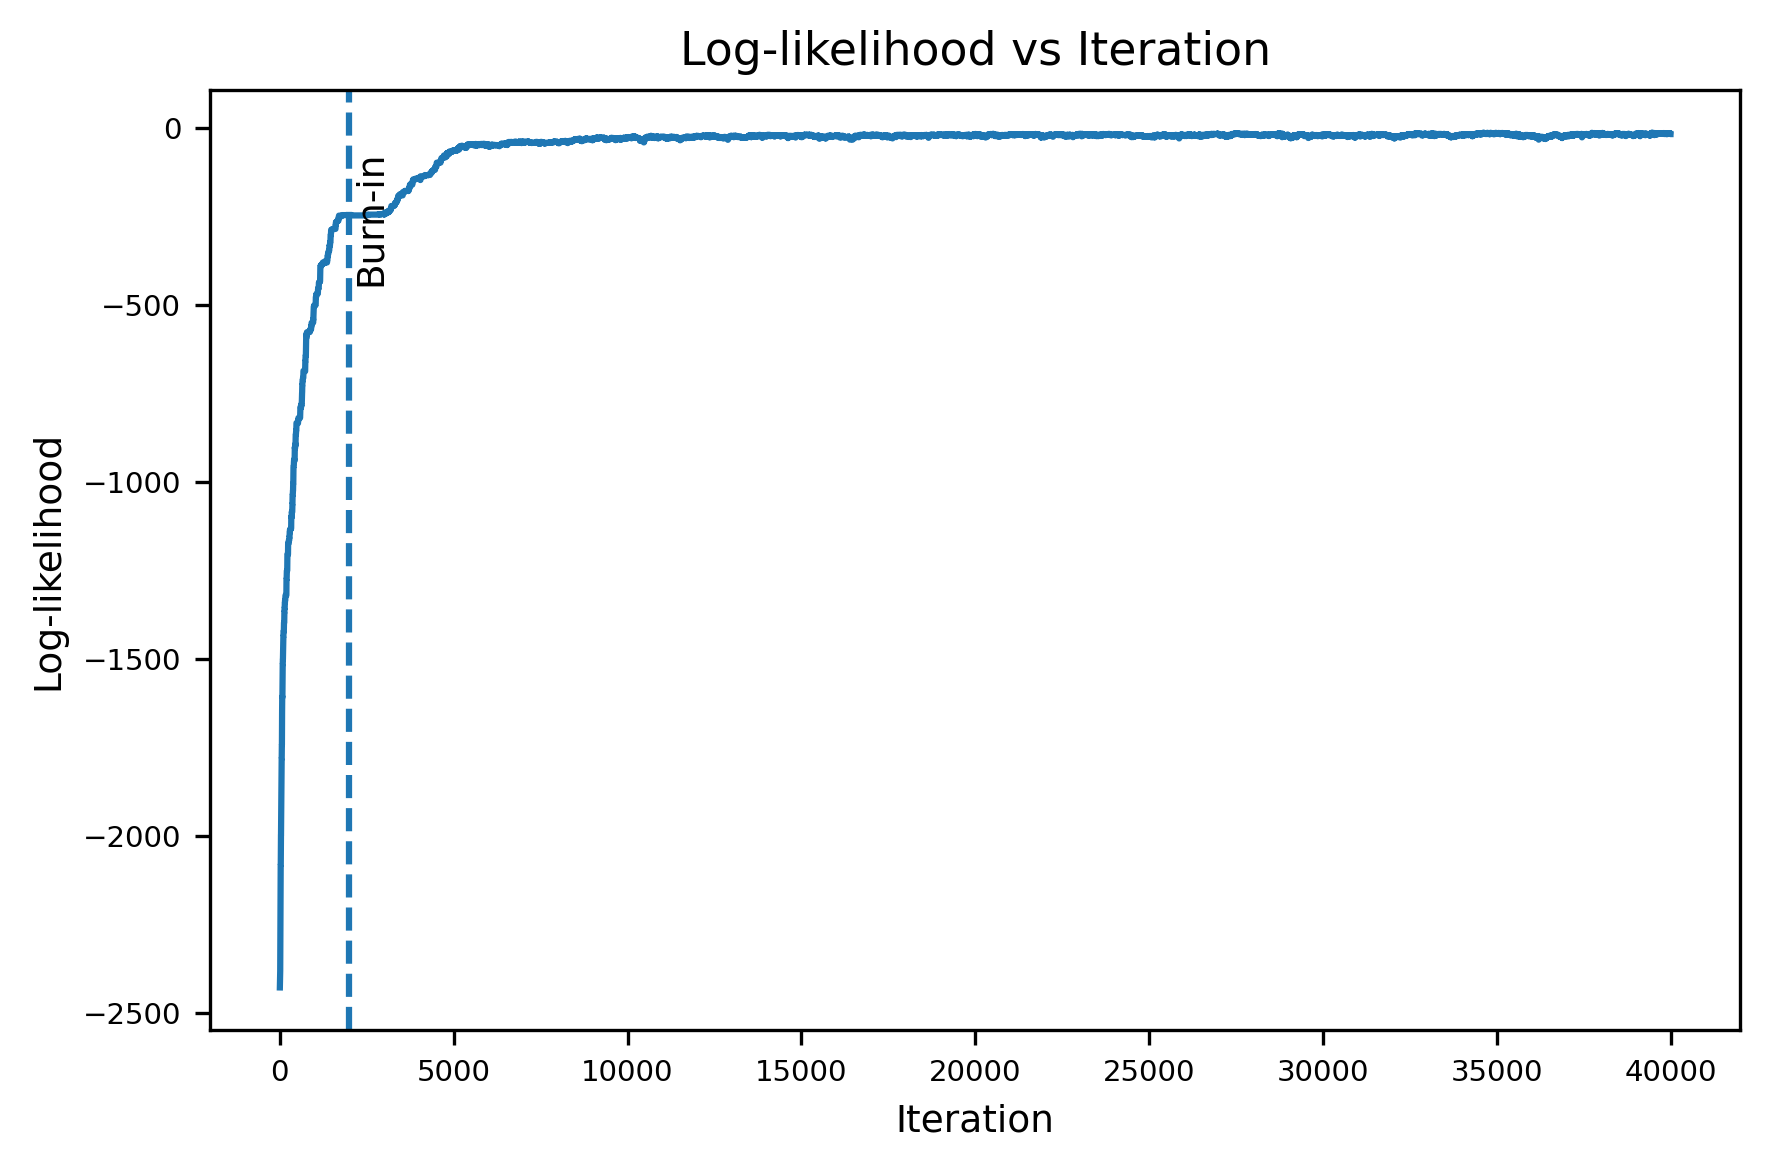

In [102]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)

burn_in = 2000

ax.plot(loss_evolution)
ax.axvline(burn_in, linestyle='--')

ax.text(
    burn_in + 100,                     # shift slightly right
    max(loss_evolution) * 5,         # near top
    "Burn-in",
    fontsize=9,
    rotation=90,
    va='top'
)

ax.set_title("Log-likelihood vs Iteration", fontsize=11, loc='center', pad=6)
ax.set_xlabel("Iteration", fontsize=9)
ax.set_ylabel("Log-likelihood", fontsize=9)


ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('loss_curve.png', bbox_inches='tight', dpi=300)
plt.show()

<class 'torch.Tensor'>
torch.Size([1, 1, 64, 64])


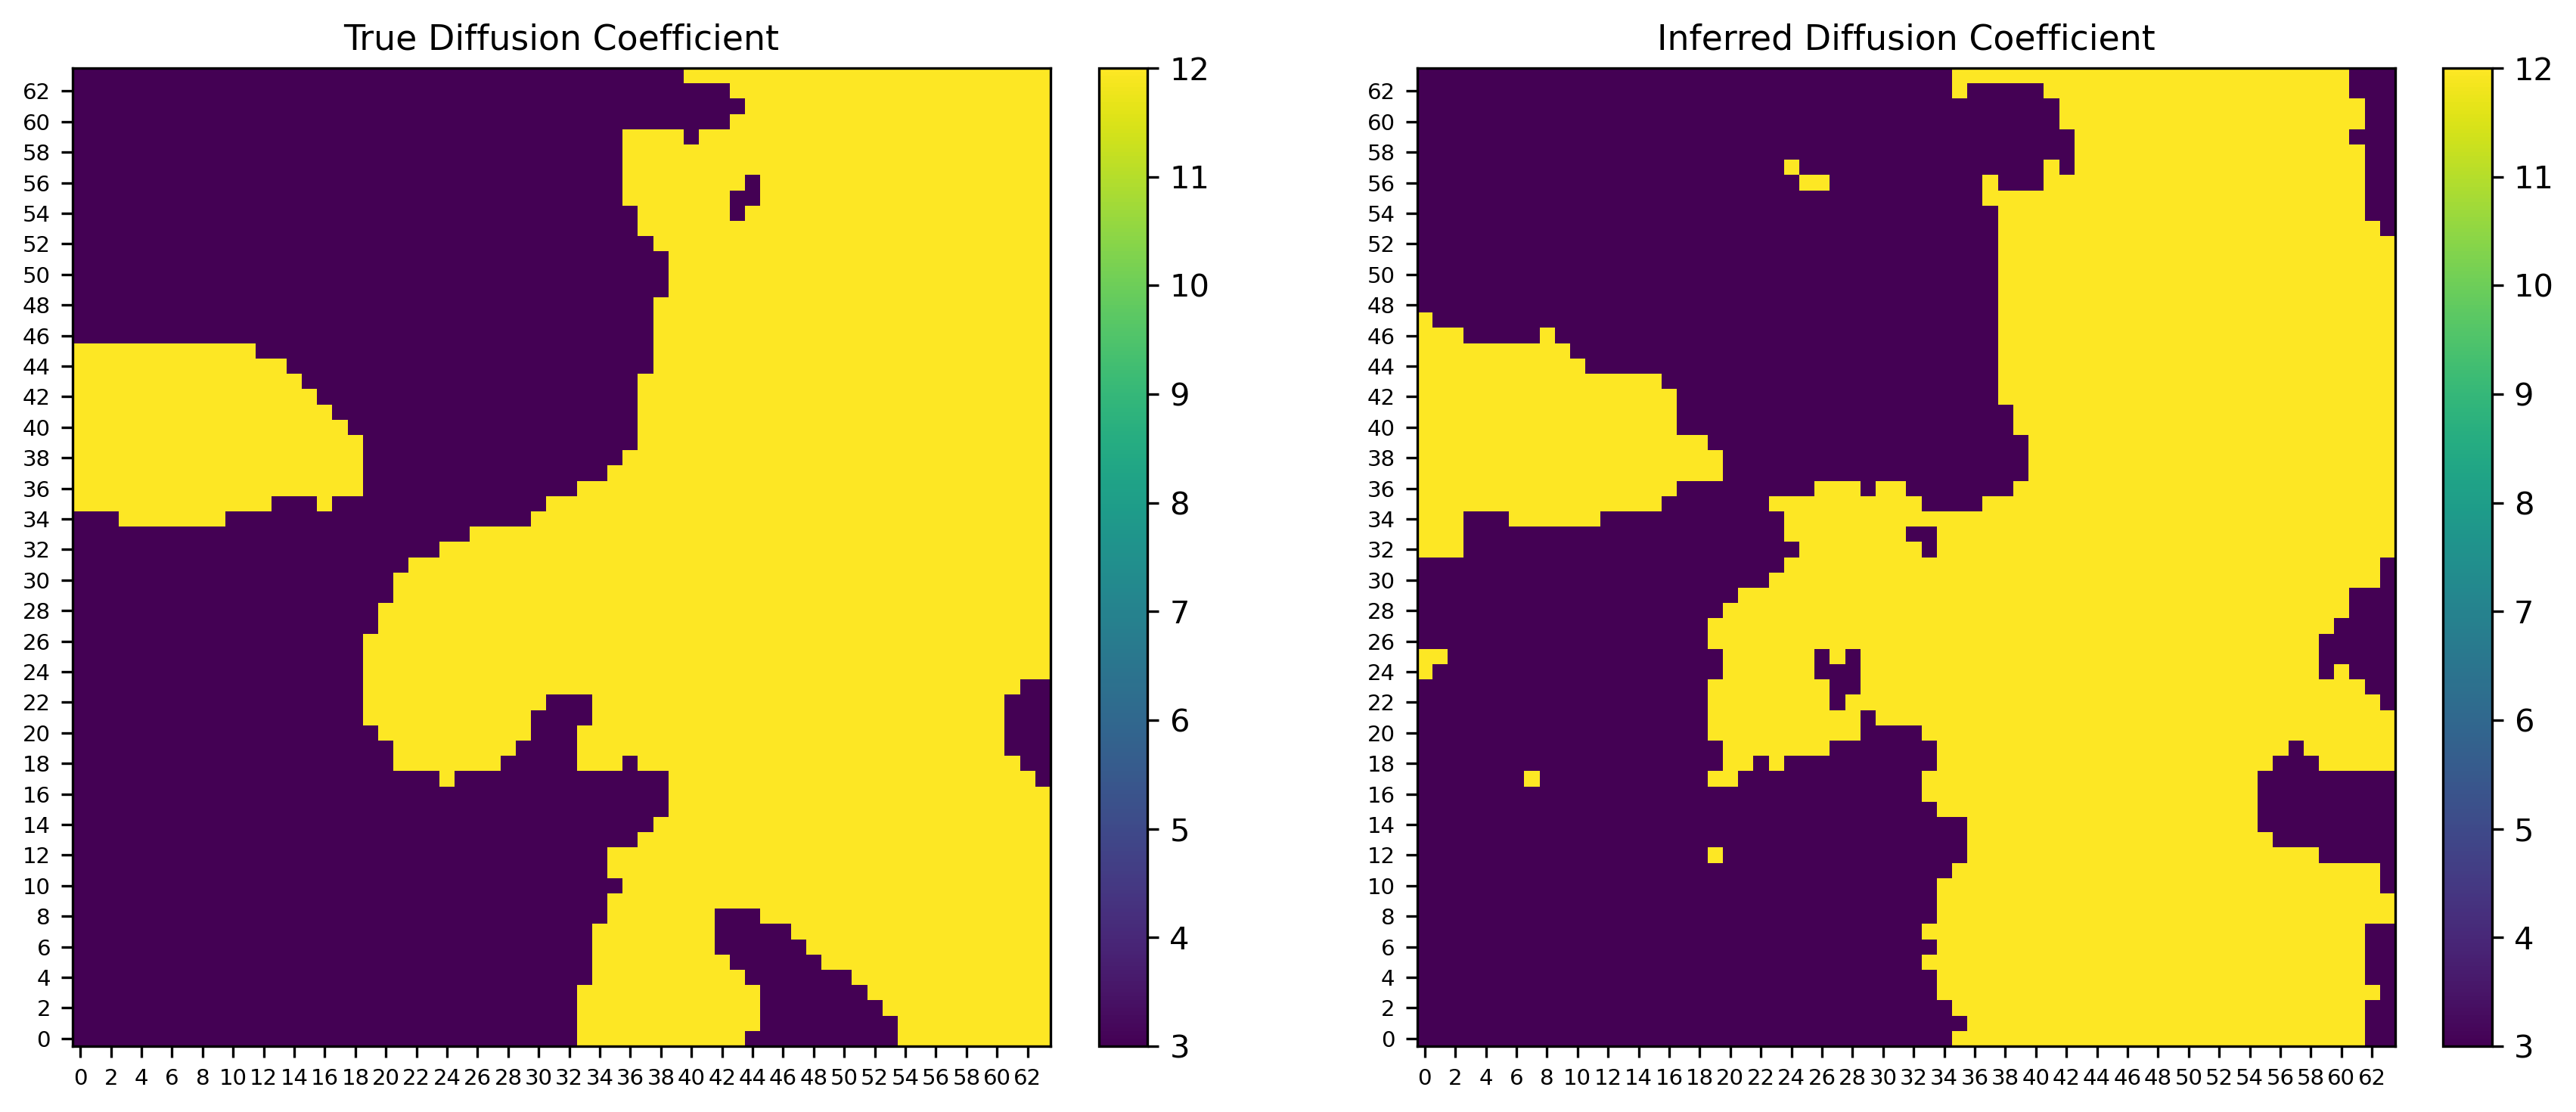

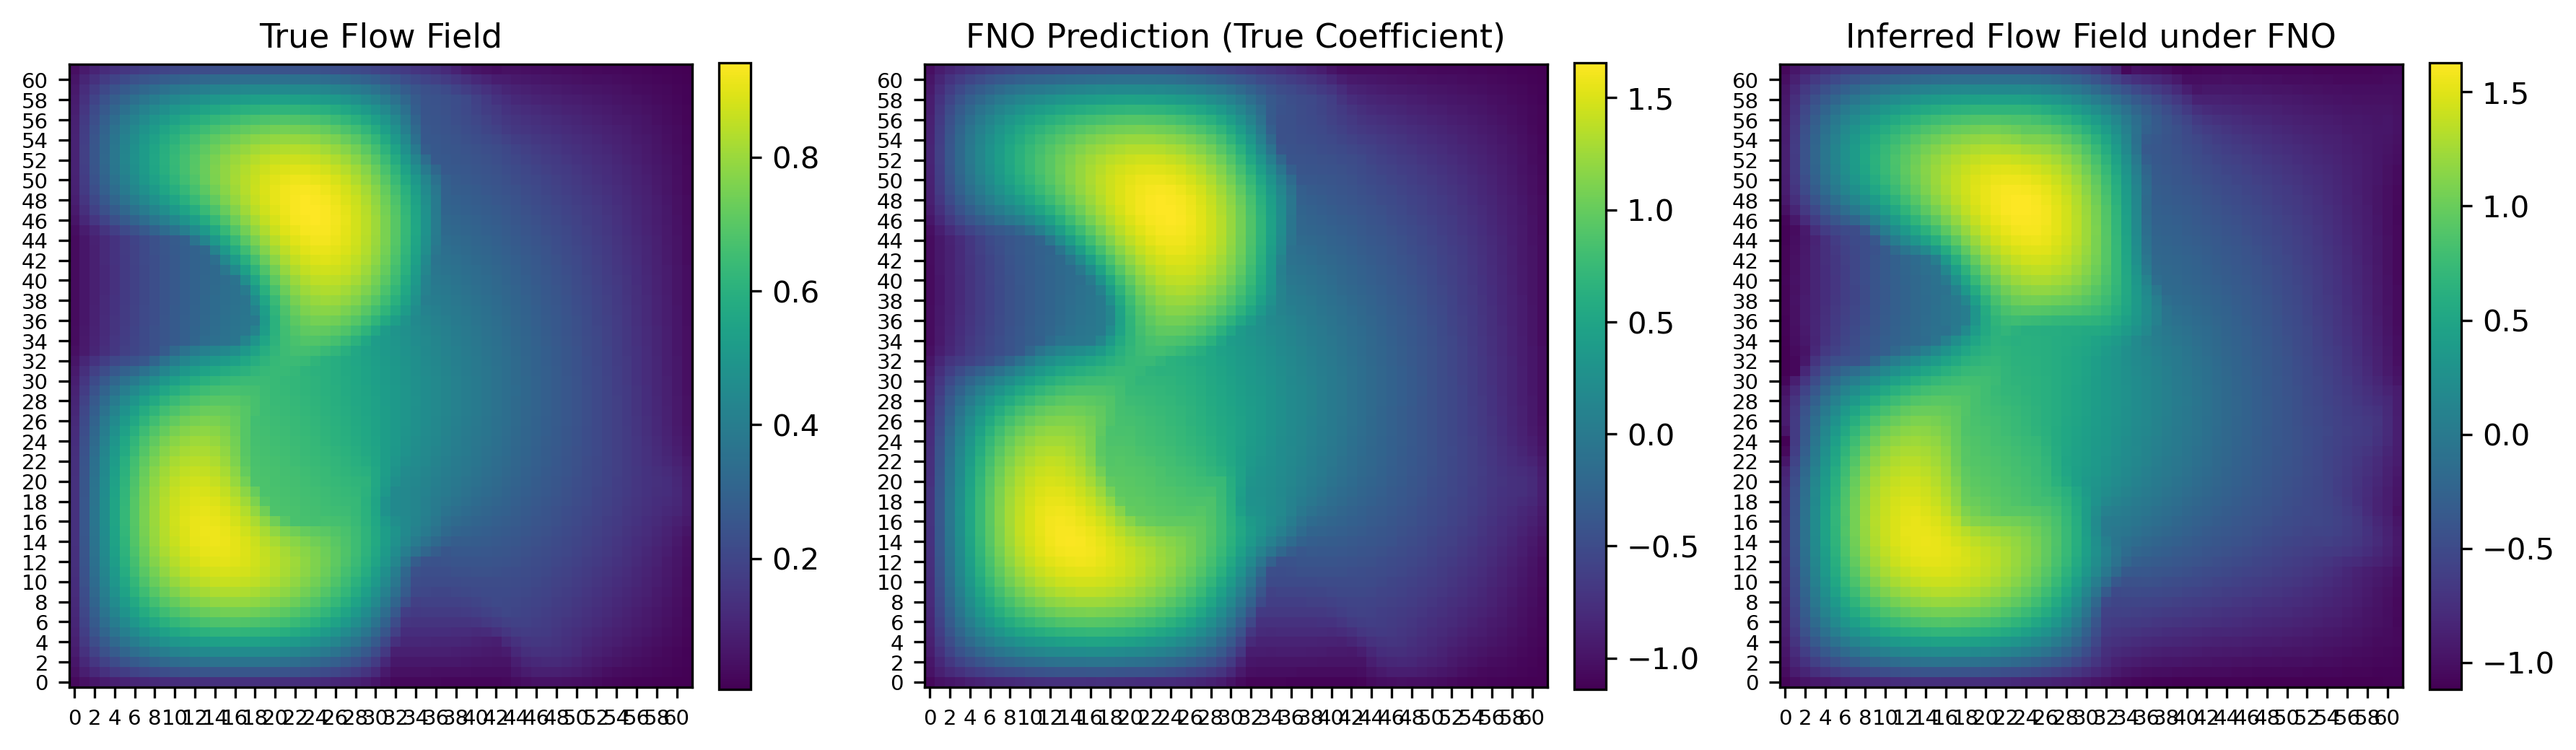

In [123]:
with torch.no_grad():
    forwards = model(true_field[0,0].unsqueeze(0).unsqueeze(0).to(device))

# Compute predicted solution
average_predicted_field = T_push(torch.from_numpy(np.mean(theta_evolution[-1000:], axis=0)), tau=-1, boundary=7.5).unsqueeze(0).unsqueeze(0)
print(type(theta_0_tensor))
print(average_predicted_field.shape)
with torch.no_grad():
    predicted_solution = model(average_predicted_field.to(device)).cpu().numpy()[0, 0]

average_predicted_field = average_predicted_field.squeeze(0).squeeze(0)

# FNO forward pass on true field
fno_prediction = forwards.cpu().numpy()[0, 0]

# ----------------------
# First figure (top row)
# ----------------------
fig1, axs1 = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

fields1 = [
    true_field.cpu().numpy()[0, 0],
    average_predicted_field,
]

titles1 = [
    "True Diffusion Coefficient",
    "Inferred Diffusion Coefficient",
]

for ax, field, title in zip(axs1, fields1, titles1):
    im = ax.imshow(field, cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(title, fontsize=11, loc='center', pad=6)
    ax.set_xticks(range(0, field.shape[0], 2))
    ax.set_yticks(range(0, field.shape[1], 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('true_vs_inferred_coefficients.png', bbox_inches='tight', dpi=300)


# ----------------------
# Second figure (bottom row)
# ----------------------
fig2, axs2 = plt.subplots(1, 3, figsize=(12, 4), dpi=300)

fields2 = [
    true_observations.cpu().numpy()[0, 0],
    fno_prediction,
    predicted_solution,
]

titles2 = [
    "True Flow Field",
    "FNO Prediction (True Coefficient)",
    "Inferred Flow Field under FNO",
]

for ax, field, title in zip(axs2, fields2, titles2):
    im = ax.imshow(field[1:field.shape[0]-1, 1:field.shape[1]-1], cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(title, fontsize=11, loc='center', pad=6)
    ax.set_xticks(range(0, field.shape[0]-2, 2))
    ax.set_yticks(range(0, field.shape[1]-2, 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('true_vs_inferred_flows.png', bbox_inches='tight', dpi=300)

plt.show()

In [104]:
# FNO error on the true coefficient -- this is your best possible NLL
theta_true_tensor = torch.tensor(true_field.cpu().numpy()[0, 0], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
ll_true = log_likelihood(theta_true_tensor, true_observations, model, sigma=sigma)
print(f"NLL with true coefficient: {ll_true:.2f}")
print(f"NLL of MCMC solution:      {ll_current:.2f}")

NLL with true coefficient: -4.51
NLL of MCMC solution:      -16.49


In [105]:
# Estimate a reasonable sigma from the FNO's own error on the true field
with torch.no_grad():
    fno_pred = model(theta_true_tensor)
    # unnormalise...
    residuals = (true_observations - fno_pred[0,0])
    print(f"Suggested sigma: {residuals.std().item():.4f}")

Suggested sigma: 0.5342


Text(0.5, 1.0, 'Mean absolute change per step')

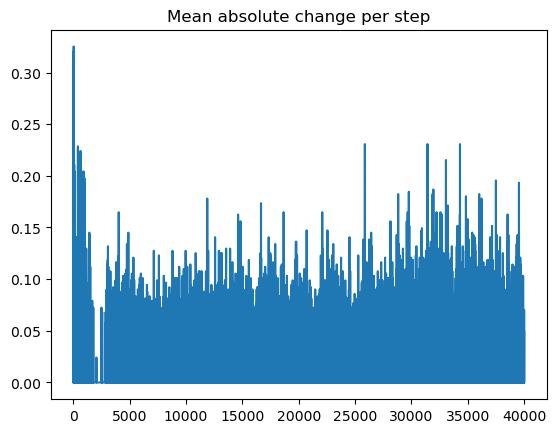

In [106]:
# Plot how much the chain moves each step
diffs = [np.mean(np.abs(theta_evolution[i] - theta_evolution[i-1])) 
         for i in range(1, len(theta_evolution))]
plt.plot(diffs)
plt.title("Mean absolute change per step")

In [107]:
import numpy as np
from mpi4py import MPI
from dolfinx import mesh, fem
from dolfinx.fem.petsc import LinearProblem
import ufl
from scipy.interpolate import griddata
import torch

def solve_FEM(theta):
    """
    Solve Darcy flow PDE given a discretised permeability field.
    
    Parameters
    ----------
    theta : np.ndarray or torch.Tensor of shape (H, W)
        Binary/continuous permeability field (values in {3, 12} or similar).
        The mesh resolution is inferred adaptively from the input shape.
    
    Returns
    -------
    u_out : same type and shape as theta
        The pressure/flow field solving -∇·(a(x)∇u) = 1 on [0,1]²
        with homogeneous Dirichlet BCs.
    """
    is_tensor = isinstance(theta, torch.Tensor)
    theta_np = theta.numpy() if is_tensor else np.asarray(theta)

    H, W = theta_np.shape  # infer resolution from input

    # ── 1. MESH ───────────────────────────────────────────────────────────────
    domain = mesh.create_unit_square(MPI.COMM_WORLD, H, W)

    # ── 2. PERMEABILITY FIELD a(x) ────────────────────────────────────────────
    # DG0: piecewise constant per triangle cell
    V_k = fem.functionspace(domain, ("DG", 0))
    a_func = fem.Function(V_k)

    tdim = domain.topology.dim
    num_cells = domain.topology.index_map(tdim).size_local
    midpoints = mesh.compute_midpoints(domain, tdim, np.arange(num_cells))

    # Map each cell midpoint → pixel index in theta
    ix = np.clip((midpoints[:, 0] * W).astype(int), 0, W - 1)
    iy = np.clip((midpoints[:, 1] * H).astype(int), 0, H - 1)

    # Permeability: high (1.0) where theta is large, low (1e-3) elsewhere
    threshold = 0.5 * (theta_np.min() + theta_np.max())
    a_func.x.array[:] = np.where(theta_np[iy, ix] > threshold, 1.0, 1e-3)

    # ── 3. FUNCTION SPACE & BCs ───────────────────────────────────────────────
    V = fem.functionspace(domain, ("Lagrange", 1))

    fdim = tdim - 1
    all_boundary_facets = mesh.locate_entities_boundary(
        domain, fdim, lambda x: np.full(x.shape[1], True, dtype=bool)
    )
    bc = fem.dirichletbc(
        fem.Constant(domain, 0.0),
        fem.locate_dofs_topological(V, fdim, all_boundary_facets),
        V,
    )

    # ── 4. VARIATIONAL FORM ───────────────────────────────────────────────────
    # -∇·(a(x)∇u) = 1  →  ∫ a ∇u·∇v dx = ∫ v dx
    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)
    a_form = a_func * ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
    L_form = v * ufl.dx

    # ── 5. SOLVE ──────────────────────────────────────────────────────────────
    problem = LinearProblem(
        a_form, L_form, bcs=[bc],
        petsc_options_prefix="darcy",
        petsc_options={
            "ksp_type": "cg",
            "pc_type": "hypre",
            "pc_hypre_type": "boomeramg",
        },
    )
    uh = problem.solve()

    # ── 6. INTERPOLATE BACK ONTO H×W GRID ────────────────────────────────────
    coords = V.tabulate_dof_coordinates()[:, :2]
    u_vals = uh.x.array.real

    grid_x, grid_y = np.meshgrid(
        np.linspace(0, 1, W), np.linspace(0, 1, H)
    )
    u_grid = griddata(coords, u_vals, (grid_x, grid_y), method="linear")

    # Fill any boundary NaNs from griddata with 0 (matches Dirichlet BC)
    u_grid = np.nan_to_num(u_grid, nan=0.0)

    # ── 7. RETURN SAME TYPE AS INPUT ──────────────────────────────────────────
    if is_tensor:
        return torch.tensor(u_grid, dtype=theta.dtype)
    return u_grid.astype(theta_np.dtype)

<class 'torch.Tensor'> torch.Size([64, 64])
[[-1.1603487 -1.1459998 -1.144589  ... -1.1378672 -1.1403089 -1.1417857]
 [-1.1492897 -1.0784538 -1.0199227 ... -1.1039466 -1.099803  -1.110805 ]
 [-1.1478649 -1.022284  -0.9128559 ... -1.0855564 -1.0950392 -1.1074524]
 ...
 [-1.1499292 -0.9998227 -0.8724215 ... -1.041203  -1.0353001 -1.0668977]
 [-1.1457927 -1.0434846 -0.9540824 ... -1.0693496 -1.0551757 -1.0789089]
 [-1.144039  -1.0865513 -1.038657  ... -1.0950854 -1.0819976 -1.0978929]]


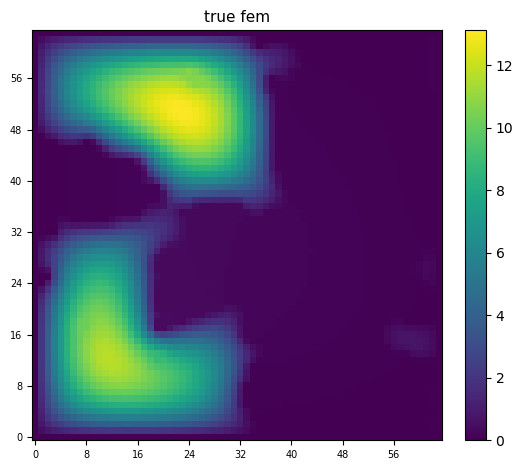

In [134]:
print(type(average_predicted_field), average_predicted_field.shape)
true_fem = solve_FEM(average_predicted_field)
print(field)
title = "true fem"

fig, ax = plt.subplots()
im = ax.imshow(true_fem, cmap='viridis', interpolation='nearest', origin='lower')
ax.set_title(title, fontsize=11, loc='center', pad=6)
ax.set_xticks(range(0, true_fem.shape[0]-2, 8))
ax.set_yticks(range(0, true_fem.shape[1]-2, 8))
ax.tick_params(labelsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('single_field.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
h1loss = H1Loss(d=2)
# true_fem = torch.from_numpy(true_fem)
h1loss(true_fem.to(device), true_observations.squeeze(0).squeeze(0))

tensor(28.8813, device='cuda:0')

In [138]:
l2loss = LpLoss(d=2, p=2)
# true_fem = torch.from_numpy(true_fem)
l2loss(true_fem.to(device), true_observations.squeeze(0).squeeze(0))

tensor(9.3548, device='cuda:0')